# WavLM Evaluation - Centroid Analysis & Visualization

This notebook provides a comprehensive evaluation of WavLM embeddings using hierarchical centroid analysis.
It includes:
1. **Speaker Assignment**: Evaluating acoustic uniqueness.
2. **Distance Tables**: Statistical breakdown of distances to centroids.
3. **Interactive Visualization**: Spider plots and global centroid maps.

In [3]:
import os
import sys
import pandas as pd
import numpy as np
import ipywidgets as widgets
from IPython.display import display

# Display settings
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# Add root directory to sys.path
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from embeddings_eval.data_loader import load_embeddings, load_metadata
from embeddings_eval.analyzer import WavLMAnalyzer
from embeddings_eval.reporter import WavLMReporter
from embeddings_eval.visualizer import WavLMVisualizer
from embeddings_eval.constants import ALL_GROUPS

In [4]:
DATA_DIR = "../datalocal/PC-GITA_v260210_24kHz/speaker_embeddings/wavLM"
META_PATH = "../datalocal/PC-GITA_v260210_24kHz/_metadata/PCGITAtoPD_mapping.csv"

print("Loading data and metadata...")
metadata = load_metadata(META_PATH)
embeddings = load_embeddings(DATA_DIR, metadata=metadata)
analyzer = WavLMAnalyzer(embeddings)
reporter = WavLMReporter(analyzer)
visualizer = WavLMVisualizer(analyzer)

print(f"Loaded {len(embeddings)} samples across {len(analyzer.speaker_centroids[analyzer.versions[0]])} speakers.")

Loading data and metadata...
Loaded 2964 samples across 100 speakers.


# 1. Centroid-Based Speaker Assignment

Evaluates how successfully individual files are assigned to the correct speaker centroid.

In [5]:
class_df = reporter.generate_classification_report()
agg_df_centroid = reporter.generate_aggregated_classification_report(class_df)

total_all = agg_df_centroid['total samples'].sum()
correct_all = agg_df_centroid['correct samples'].sum()
accuracy_all = (correct_all / total_all) * 100

print("--- GLOBAL CENTROID SUMMARY ---")
print(f"Total samples: {total_all}")
print(f"Correctly assigned to speaker: {correct_all}")
print(f"Global Accuracy: {accuracy_all:.2f}%")
print("------------------------------")

display(agg_df_centroid)
print("\nDetailed Results (Top 5 Intruders):")
display(class_df)

Classifying samples to centroids:   0%|          | 0/2964 [00:00<?, ?it/s]

--- GLOBAL CENTROID SUMMARY ---
Total samples: 2964
Correctly assigned to speaker: 2538
Global Accuracy: 85.63%
------------------------------


,status,group,total samples,correct samples,accuracy %
0,HC,monologue,408,362,88.725490
1,HC,readtext,280,228,81.428571
2,HC,sentence,467,431,92.291221
3,HC,words,225,201,89.333333
4,PD,ddk,300,202,67.333333
5,PD,monologue,386,342,88.601036
6,PD,readtext,270,217,80.370370
7,PD,sentence,423,372,87.943262
8,PD,words,205,183,89.268293



Detailed Results (Top 5 Intruders):


,speaker id,group,status,total samples,correct samples,accuracy %,top 5 intruders
0,001PD,ddk,PD,6,5,83.333333,016PD_ddk (16.7%)
1,001PD,monologue,PD,8,8,100.000000,
2,001PD,readtext,PD,5,5,100.000000,
3,001PD,sentence,PD,10,10,100.000000,
4,001PD,words,PD,5,5,100.000000,
5,002PD,ddk,PD,6,5,83.333333,012PD_ddk (16.7%)
6,002PD,monologue,PD,12,8,66.666667,"005PD_readtext (16.7%), 004PD_ddk (8.3%), 055E..."
7,002PD,readtext,PD,5,5,100.000000,
8,002PD,sentence,PD,10,9,90.000000,003PD_sentence (10.0%)
9,002PD,words,PD,5,4,80.000000,048PD_ddk (20.0%)


# 2. Statistical Distance Tables

Detailed Mean/Variance metrics for distances to group and speaker centroids.

In [6]:
detailed_df = reporter.generate_detailed_report(calculate_samples=False)
summaries = reporter.generate_summary_reports(detailed_df)

print("PD Group Summary:")
display(summaries['PD'])
print("\nHC Group Summary:")
display(summaries['HC'])

Calculating distances (sample vs centroids):   0%|          | 0/2964 [00:00<?, ?it/s]

PD Group Summary:


,speaker id,group,dist group mean,dist group var,dist speaker mean,dist speaker var,centroid nearest other group,centroid nearest other group dist
0,001PD,ddk,0.061058,0.000764,0.135330,0.004895,076EHC_monologue,0.078102
1,001PD,monologue,0.010796,0.000029,0.013971,0.000039,076EHC_readtext,0.066068
2,001PD,readtext,0.022188,0.000044,0.029713,0.000191,076EHC_readtext,0.063659
3,001PD,sentence,0.029166,0.000453,0.031309,0.000630,076EHC_readtext,0.053124
4,001PD,words,0.016852,0.000069,0.027668,0.000464,076EHC_readtext,0.037373
5,002PD,ddk,0.058490,0.000870,0.144736,0.003213,003PD_ddk,0.052951
6,002PD,monologue,0.076328,0.019192,0.081091,0.025718,005PD_readtext,0.026961
7,002PD,readtext,0.022856,0.000101,0.034449,0.000194,005PD_readtext,0.022268
8,002PD,sentence,0.037469,0.000153,0.041941,0.000338,049PD_monologue,0.031399
9,002PD,words,0.035022,0.000263,0.049579,0.000470,005PD_readtext,0.042679



HC Group Summary:


,speaker id,group,dist group mean,dist group var,dist speaker mean,dist speaker var,centroid nearest other group,centroid nearest other group dist
0,041YHC,monologue,0.017144,0.000113,0.020972,0.000160,029PD_readtext,0.022642
1,041YHC,readtext,0.020412,0.000016,0.023998,0.000054,029PD_readtext,0.024524
2,041YHC,sentence,0.023326,0.000126,0.026312,0.000261,029PD_readtext,0.028553
3,041YHC,words,0.019001,0.000075,0.026405,0.000231,029PD_readtext,0.041224
4,042YHC,monologue,0.015061,0.000143,0.020964,0.000193,019PD_words,0.034863
5,042YHC,readtext,0.033982,0.000192,0.040228,0.000364,019PD_words,0.027871
6,042YHC,sentence,0.023835,0.000061,0.026321,0.000106,019PD_words,0.022893
7,042YHC,words,0.024850,0.000030,0.036939,0.000224,019PD_words,0.025717
8,043EHC,monologue,0.019316,0.000047,0.027351,0.000052,047EHC_monologue,0.052612
9,043EHC,readtext,0.035930,0.000222,0.046771,0.000299,005PD_readtext,0.020703


In [7]:
print("Detailed Speaker Search:")
def show_speaker_details(speaker_id):
    filtered = detailed_df[detailed_df['speaker id'] == speaker_id]
    display(filtered)

speaker_list = sorted(detailed_df['speaker id'].unique())
widgets.interact(show_speaker_details, speaker_id=speaker_list);

Detailed Speaker Search:


interactive(children=(Dropdown(description='speaker_id', options=('001PD', '002PD', '003PD', '004PD', '005PD',…

# 3. Visual Exploration

## 3.1 Global Centroid Map
Overall clusters of all speakers and their task-group centroids.

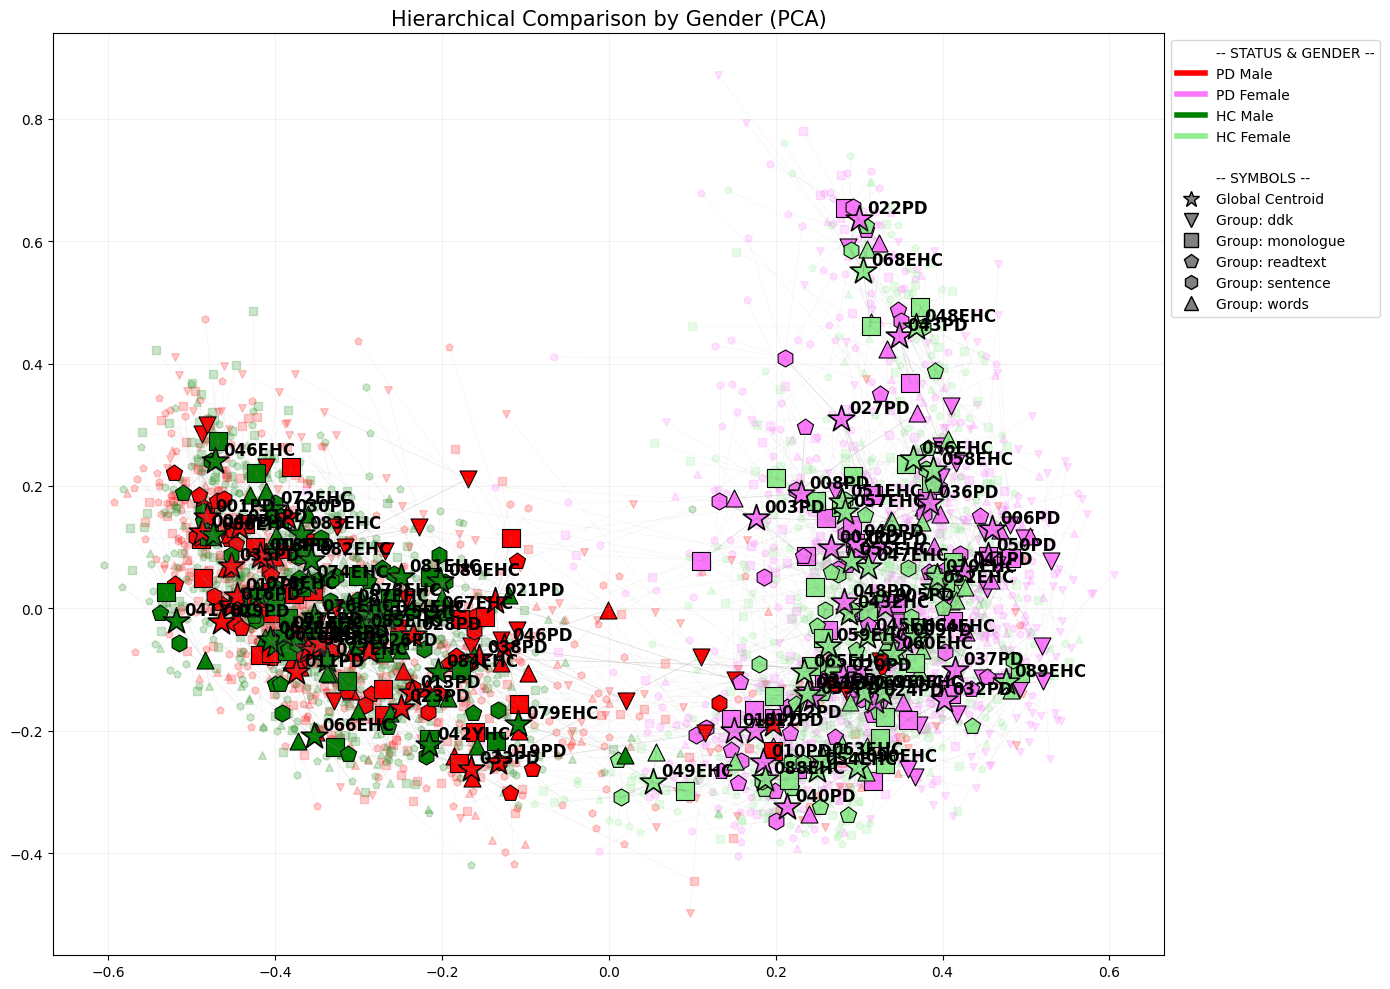

In [8]:
visualizer.plot_centroids(method='pca')

## 3.2 Interactive Spider Plots
Select speakers to see hierarchical connections: Sample -> Group Centroid -> Speaker Centroid.

In [ ]:
def update_plot(method, selected_speakers):
    if not selected_speakers: return
    visualizer.plot_speaker_comparison(list(selected_speakers), method=method.lower())

ver = analyzer.versions[0]
speakers = sorted(list(analyzer.speaker_centroids[ver].keys()))
method_dropdown = widgets.Dropdown(options=['PCA', 't-SNE'], value='PCA', description='Method:')
speaker_select = widgets.SelectMultiple(options=speakers, value=[speakers[0]], description='Speakers:', rows=10)

widgets.interactive(update_plot, method=method_dropdown, selected_speakers=speaker_select)

interactive(children=(Dropdown(description='Method:', options=('PCA', 't-SNE'), value='PCA'), SelectMultiple(d…